# Quy trình hệ thống chạy — từng bước, chỉnh được, thực nghiệm trực tiếp

Notebook `01` giải thích **mô hình** (dữ liệu, đồ thị, huấn luyện). Notebook này chạy **cả hệ thống** như khi người dùng
gọi `assess("…", L_peak=150)`, nhưng **tách từng bước ra** để bạn xem đầu vào/đầu ra của mỗi bước và **đổi tham số
rồi chạy lại**.

```
 Yêu cầu (tiếng Việt/Anh)
   │
   ▼  BƯỚC 1  ParserAgent ── luật (từ khoá) → LLM → 6 guard (G1–G6)  ⇒ archetype, Δ, dịch vụ
   │
   ▼  BƯỚC 2  ArchitectureAgent ── quét đồ thị phụ thuộc                ⇒ vùng ảnh hưởng
   │
   ├─▶ BƯỚC 3  TẦNG 1 — CapacityAgent (Global Causal DAG)            ⇒ CPU/mem/độ trễ dự kiến, biên dự phòng
   │
   └─▶ BƯỚC 4  TẦNG 2 — bộ dự đoán khả thi (u_s vs u*, cổng throttling) ⇒ FEASIBLE / MARGINAL / INFEASIBLE, điểm gãy R*
```

**Cách dùng:**
1. Chọn kernel **`.venv`**, *Run All* một lần (~1 phút) để thấy cấu hình mặc định.
2. Sửa **ô CẤU HÌNH** (mục 0), rồi *Run All* lại — hoặc chạy lại từ ô cấu hình trở xuống.
3. Muốn thử một ý tưởng mô hình: dùng **mục 6 — Bàn thực nghiệm**, kết quả tự vào **bảng xếp hạng**.

**Bảo đảm an toàn:** mọi thay đổi ở đây chỉ nằm **trong bộ nhớ** của notebook — không ghi file nào, không đụng file đóng
băng, không sửa `src/`. Tắt kernel là mọi thứ về như cũ. Đừng chạy khi đang đo ramp (làm nhiễu phép đo).

> **Phát triển ≠ tiến cứu.** Mọi so sánh ở mục 6 dùng dữ liệu đáp án **đã xem**. Một biến thể thắng ở đây mới chỉ là
> ứng viên; muốn gọi là tiến cứu phải đưa vào `src/` (chế độ mới), đóng băng bằng script, commit **và push**, rồi đo
> trên tính năng **mới** (mục 7).

In [1]:
import glob, json, os, sys, re, copy, contextlib, io, warnings
from dataclasses import asdict
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, networkx as nx

ROOT = Path.cwd()
while not (ROOT / 'src').exists():
    ROOT = ROOT.parent
# Duong dan TU TIM: tu lan tach hai bai, experiments/ da sang papers/<bai>/experiments/.
# Ghi tay 'experiments/collect' la nguon muc rua -- chinh no lam notebook nay vo 19/39 o.
_duong = ['src', 'src/agents', 'src/scm']
_duong += [str(p.relative_to(ROOT)) for p in sorted(ROOT.glob('papers/*/experiments/*'))
           if p.is_dir() and p.name != 'archive' and any(p.glob('*.py'))]
_duong += [str(p.relative_to(ROOT)) for p in sorted(ROOT.glob('experiments/*')) if p.is_dir()]
for p in _duong:
    if str(ROOT / p) not in sys.path:
        sys.path.insert(0, str(ROOT / p))
warnings.filterwarnings('ignore'); os.environ.setdefault('TQDM_DISABLE', '1')
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40); pd.set_option('display.max_colwidth', 120)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3})
FROZEN, RAW = ROOT / 'data/processed/frozen', ROOT / 'data/raw'

# Giai ten bo du lieu qua `data/manifest.json` (sinh boi
# papers/p1_du_phong/experiments/collect/sinh_manifest_du_lieu.py) thay vi ghi tay:
# SS-PROSP2 long 3 cap -- data/raw/SS-PROSP2/SS-PROSP2/ramp_*.
try:
    MANIFEST = json.load(open(ROOT / 'data' / 'manifest.json', encoding='utf-8'))['bo_du_lieu']
except FileNotFoundError:
    MANIFEST = {}

def bo(ten):
    '''Thu muc THAT chua cac ramp_* cua mot bo du lieu.'''
    if ten in MANIFEST:
        return ROOT / MANIFEST[ten]['duong_dan']
    for k, v in MANIFEST.items():
        if k.split('/')[-1] == ten:
            return ROOT / v['duong_dan']
    d = RAW / ten
    return d if list(d.glob('ramp_*')) else next((q for q in sorted(d.glob('*')) if list(q.glob('ramp_*'))), d)

@contextlib.contextmanager
def quiet():
    """an log dai (dowhy, agent). Muon xem log: thay `with quiet():` bang `if True:`"""
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        yield

import feasibility_predictor as FP
import parser_agent as PA
import capacity_agent as CA
import load_sweep_collect as HARNESS
from request_router import SOCKSHOP_CALL_CHAINS, classify_request
from architecture_agent import ArchitectureAgent
try:
    display
except NameError:
    display = print
print('goc repo:', ROOT)

goc repo: /Users/ngkky/NCKH/NCKH


## 0. ⚙️ CẤU HÌNH — mọi núm chỉnh nằm ở đây

Giá trị mặc định = **đúng cấu hình hệ thống đang dùng** (bản đóng băng). Sửa một giá trị rồi chạy lại từ ô này trở xuống.

In [2]:
CAU_HINH = dict(
    # ---------------- ĐẦU VÀO ----------------
    YEU_CAU = "Khách hàng muốn đăng nhập nhanh chỉ bằng một nút",
    L_PEAK  = 150,             # tải đỉnh kỳ vọng (req/s). None = chỉ chạy Tầng 1 (dự báo), không phán quyết
    K       = 'probe',         # bội số gọi k: None (P2, giả định k=1) | 'probe' (lấy từ file probe theo archetype)
                               #   | 'probe:login' (của một tính năng cụ thể) | dict vd {'user': 1, 'carts': 1}

    # ---------------- LLM (BƯỚC 1) ----------------
    LLM = 'offline',           # 'offline'  : không gọi LLM -> Parser lùi về luật (giống máy hiện tại, chưa có API key)
                               # 'gia_lap'  : LLM giả trả đúng JSON ở LLM_GIA_LAP -> thử guard G1–G6 với đầu ra xấu
                               # tên backend: vd 'gemini-3.5-flash-lite' (cần API key trong .env; TỐN PHÍ)
    LLM_GIA_LAP = {            # chỉ dùng khi LLM='gia_lap'. Thử: injection_service='orders' (G1),
        'is_customer_facing_feature': True,     #   adjustment=40 (G3), core_services=['redis'] (G4),
        'is_customer_facing_confidence': 'HIGH',#   is_customer_facing_feature=False (G6)
        'request_type': 'LOGIN', 'core_services': ['front-end', 'user'],
        'injection_service': 'front-end', 'adjustment': 5.0,
        'reasoning': 'LLM gia lap', 'confidence': 'HIGH'},

    # ---------------- GUARD CỦA PARSER ----------------
    MAX_ADJUSTMENT_PCT   = 10.0,   # G3: LLM chỉ được lệch ±x% so với anchor của archetype
    MIN_DELTA_PCT        = 5.0,    # G2: sàn Δ
    MAX_DELTA_PCT        = 50.0,   # G2: trần Δ
    SIMILARITY_THRESHOLD = 0.6,    # G5: dưới ngưỡng -> ép adjustment = 0
    TAU_PASS             = 0.5343, # G6: điểm scope-gate < TAU_PASS -> cho qua
    TAU_REFUSE           = 0.6907, # G6: >= TAU_REFUSE -> từ chối; ở giữa -> cần người xem

    # ---------------- TẦNG 1: GLOBAL CAUSAL DAG (BƯỚC 3) ----------------
    MAU_CANH_HOC = ['cpu_backpressure', 'latency_backprop_causil'],   # bỏ bớt để xem DAG không có cạnh học
    DELTA_TANG1  = None,       # None = dùng Δ của Parser; hoặc một số (%) để ép

    # ---------------- TẦNG 2: BỘ DỰ ĐOÁN KHẢ THI (BƯỚC 4) ----------------
    CHE_DO        = 'P2',          # 'P0' | 'P1' | 'P2'   (P3 = P2 + K đo được)
    CHAIN         = 'taxonomy',    # 'taxonomy' (như bản đóng băng) | 'probe' (chain đo được) | list tuỳ ý
    U_STAR        = 'dong_bang',   # 'dong_bang' (0,8783) | 'phien_tien_cuu' (từ ramp base SS-PROSP2) | một số
    U_MARGIN      = 0.10,          # MARGINAL khi max_u trong 10% dưới u*
    TRAN_CPU      = 'RE2',         # tên cấu hình trong deploy/sockshop/limits.json, hoặc dict {service: core}
    TRAIN_MAX_RPS = 150,           # chỉ dùng dữ liệu SS-TRAIN có tải <= giá trị này để fit cơ chế
    THAM_SO_P2    = 'dong_bang',   # 'dong_bang' | dict {'c': {...}, 'x': ...}
    QUOTA_MIN_CORES = 0.5,         # cổng throttling: node nghẽn dưới ngưỡng này -> UNDECIDED
    N_BOOTSTRAP   = 100,           # số lần bootstrap cho khoảng tin cậy điểm gãy (0 = tắt)
)
CH = CAU_HINH
print('cau hinh da nap:', {k: v for k, v in CH.items() if k != 'LLM_GIA_LAP'})

cau hinh da nap: {'YEU_CAU': 'Khách hàng muốn đăng nhập nhanh chỉ bằng một nút', 'L_PEAK': 150, 'K': 'probe', 'LLM': 'offline', 'MAX_ADJUSTMENT_PCT': 10.0, 'MIN_DELTA_PCT': 5.0, 'MAX_DELTA_PCT': 50.0, 'SIMILARITY_THRESHOLD': 0.6, 'TAU_PASS': 0.5343, 'TAU_REFUSE': 0.6907, 'MAU_CANH_HOC': ['cpu_backpressure', 'latency_backprop_causil'], 'DELTA_TANG1': None, 'CHE_DO': 'P2', 'CHAIN': 'taxonomy', 'U_STAR': 'dong_bang', 'U_MARGIN': 0.1, 'TRAN_CPU': 'RE2', 'TRAIN_MAX_RPS': 150, 'THAM_SO_P2': 'dong_bang', 'QUOTA_MIN_CORES': 0.5, 'N_BOOTSTRAP': 100}


In [3]:
# --- ap cau hinh vao cac module (CHI trong bo nho) ---
for k in ['MAX_ADJUSTMENT_PCT', 'MIN_DELTA_PCT', 'MAX_DELTA_PCT', 'SIMILARITY_THRESHOLD']:
    setattr(PA, k, float(CH[k]))
PA._SCOPE_GATE_CONFORMAL_TAU_PASS, PA._SCOPE_GATE_CONFORMAL_TAU_REFUSE = float(CH['TAU_PASS']), float(CH['TAU_REFUSE'])

class _Resp:
    def __init__(self, content): self.content = content

class LLMGhiLai:
    """boc mot LLM bat ky, GHI LAI prompt gui di va cau tra loi nhan ve de xem o buoc 1"""
    def __init__(self, inner): self.inner, self.nhat_ky = inner, []
    def invoke(self, messages):
        prompt = '\n'.join(getattr(m, 'content', str(m)) for m in messages)
        try:
            r = self.inner.invoke(messages); out = getattr(r, 'content', str(r))
        except Exception as e:
            out = f'<LOI: {e}>'
        self.nhat_ky.append({'prompt': prompt, 'tra_loi': out})
        return _Resp(out)

class LLMOffline:
    """giong he thong khi chua co API key: tra ve van ban khong phai JSON -> Parser lui ve luat"""
    def invoke(self, messages): return _Resp('(offline: khong co LLM)')

class LLMGiaLap:
    def __init__(self, data): self.data = data
    def invoke(self, messages): return _Resp(json.dumps(self.data, ensure_ascii=False))

if CH['LLM'] == 'offline':
    _inner = LLMOffline()
elif CH['LLM'] == 'gia_lap':
    _inner = LLMGiaLap(CH['LLM_GIA_LAP'])
else:
    from llm_backends import get_llm
    _inner = get_llm(CH['LLM'])
LLM = LLMGhiLai(_inner)
arch = ArchitectureAgent(str(ROOT / 'src/graph/sockshop_agent_graph.json'))
parser = PA.ParserAgent(llm=LLM, arch_agent=arch)
print('LLM:', CH['LLM'], '| gateway cua he:', sorted(parser._gateways))

[ParserAgent] Khoi tao xong (SockShop). Gateways: {'front-end'}
LLM: offline | gateway cua he: ['front-end']


## 1. BƯỚC 1 — ParserAgent: yêu cầu → can thiệp có ràng buộc

LLM **không bao giờ** được tự quyết con số cuối. Nó chỉ *đề xuất*; sáu guard xác định (G1–G6) chiếu đề xuất về vùng hợp lệ.
Vì vậy các bảo đảm cấu trúc đúng với **mọi** đầu ra của LLM — kể cả đầu ra xấu (thử bằng `LLM='gia_lap'`).

### 1.1 Gợi ý theo luật (từ khoá, bỏ dấu tiếng Việt)

In [4]:
yc = CH['YEU_CAU']
rb = classify_request(yc, parser.call_chains, parser._priority_order, parser.default_request_type)
sim = pd.DataFrame([{'archetype': a, 'do_khop_tu_khoa': PA._compute_similarity(yc, a, parser.call_chains),
                     'Delta mac dinh %': v['expected_delta_pct'], 'chuoi goi (taxonomy)': v['services']}
                    for a, v in parser.call_chains.items()]).sort_values('do_khop_tu_khoa', ascending=False)
print(f'yeu cau: "{yc}"\nluat goi y: {rb}')
display(sim.reset_index(drop=True))

yeu cau: "Khách hàng muốn đăng nhập nhanh chỉ bằng một nút"
luat goi y: LOGIN


,archetype,do_khop_tu_khoa,Delta mac dinh %,chuoi goi (taxonomy)
0,LOGIN,0.333333,10,"[front-end, user]"
1,GET_CATALOGUE,0.000000,10,"[front-end, catalogue]"
2,ADD_TO_CART,0.000000,15,"[front-end, catalogue, carts]"
3,VIEW_CART,0.000000,10,"[front-end, carts]"
4,REGISTER,0.000000,10,"[front-end, user]"
5,PLACE_ORDER,0.000000,25,"[front-end, user, catalogue, carts, orders, payment, shipping]"
6,APPLY_PROMO_CODE,0.000000,20,"[front-end, carts, orders, payment]"
7,RECOMMEND_PRODUCTS,0.000000,30,"[front-end, user, catalogue, orders]"
8,TRACK_PACKAGE,0.000000,15,"[front-end, orders, shipping]"
9,WRITE_PRODUCT_REVIEW,0.000000,10,"[front-end, user, catalogue]"


### 1.2 LLM và sáu guard

| Guard | Kiểm | Khi vi phạm |
|---|---|---|
| **G1** | điểm tiêm tải phải là **gateway** (node vào không có cha) | đổi về gateway trong chuỗi gọi của archetype |
| **G2** | Δ nằm trong [`MIN_DELTA_PCT`, `MAX_DELTA_PCT`] | kẹp vào khoảng |
| **G3** | \|Δ − anchor\| ≤ `MAX_ADJUSTMENT_PCT` | quay về anchor, độ tin cậy LOW |
| **G4** | dịch vụ phải sửa **có thật** trong đồ thị | loại dịch vụ bịa |
| **G5** | độ khớp từ khoá ≥ `SIMILARITY_THRESHOLD` | ép adjustment = 0 |
| **G6** | *Scope gate*: điểm logistic của 4 tín hiệu so với hai ngưỡng hiệu chỉnh conformal | từ chối / cần người xem |

In [5]:
LLM.nhat_ky.clear()
with quiet():
    parsed = parser.parse(yc)
P = asdict(parsed)
display(pd.Series({k: P[k] for k in ['request_type', 'injection_service', 'template_delta', 'adjustment', 'injection_delta_pct',
                                     'core_services', 'affected_services', 'similarity_score', 'confidence',
                                     'is_out_of_scope', 'needs_human_review', 'scope_gate_score']}, name='ket qua Parser').to_frame())
g = P['scope_gate_score']
vung = 'TU CHOI' if g >= PA._SCOPE_GATE_CONFORMAL_TAU_REFUSE else ('CAN NGUOI XEM' if g >= PA._SCOPE_GATE_CONFORMAL_TAU_PASS else 'CHO QUA')
print(f"G6 scope gate: diem = {g:.3f} | TAU_PASS = {PA._SCOPE_GATE_CONFORMAL_TAU_PASS:.3f} | TAU_REFUSE = "
      f"{PA._SCOPE_GATE_CONFORMAL_TAU_REFUSE:.3f} -> {vung}")
print('dac trung tho cua G6:', P['scope_gate_raw_features'])
print('\nLY DO (ghi cua guard duoc noi vao):\n ', P['reasoning'])

,ket qua Parser
request_type,LOGIN
injection_service,front-end
template_delta,10
adjustment,0.0
injection_delta_pct,10.0
core_services,[front-end]
affected_services,"[front-end, user]"
similarity_score,0.333333
confidence,LOW
is_out_of_scope,False


G6 scope gate: diem = 0.095 | TAU_PASS = 0.534 | TAU_REFUSE = 0.691 -> CHO QUA
dac trung tho cua G6: {'rb_similarity': 0.3333333333333333, 'llm_pick_similarity': 0.3333333333333333, 'keyword_similarity_score': 0.3333333333333333, 'llm_is_customer_facing': True}

LY DO (ghi cua guard duoc noi vao):
  [LLM ERROR: Expecting value: line 1 column 1 (char 0)] [LOW SIMILARITY: siet ve anchor, khong dieu chinh]


In [6]:
# Prompt THAT gui cho LLM va cau tra loi nhan ve (xem de hieu LLM duoc phep lam gi)
if LLM.nhat_ky:
    nk = LLM.nhat_ky[-1]
    print(nk['prompt'][:3000] + ('\n...(cat bot)' if len(nk['prompt']) > 3000 else ''))
    print('\n========== LLM TRA LOI ==========\n', nk['tra_loi'][:1500])

Ban la Systems Analyst chuyen gia ve microservices SockShop (an online sock e-commerce store).

[CAC LOAI YEU CAU DA BIET]
  - GET_CATALOGUE: Customer views product list or detail
  - ADD_TO_CART: Customer adds item to cart
  - VIEW_CART: Customer views their cart
  - REGISTER: New customer registration
  - LOGIN: Customer login
  - PLACE_ORDER: Customer places a full order (heaviest operation)
  - APPLY_PROMO_CODE: NEW FEATURE: Customer applies discount promo code or voucher during checkout
  - RECOMMEND_PRODUCTS: NEW FEATURE: Smart product recommendations based on shopping history
  - TRACK_PACKAGE: NEW FEATURE: Real-time package tracking and delivery status
  - WRITE_PRODUCT_REVIEW: NEW FEATURE: Customer writes a review and rates a purchased product

[CAC DICH VU TRONG HE THONG]
  - front-end: 
  - catalogue: 
  - carts: 
  - orders: 
  - payment: 
  - user: 
  - shipping: 


[BANG HIEU CHINH (Calibration Table — tu du lieu thuc nghiem)]
  GET_CATALOGUE             | anchor=10% | 2 

## 2. BƯỚC 2 — ArchitectureAgent: vùng ảnh hưởng

Với mỗi dịch vụ Parser trả về, quét đồ thị phụ thuộc để biết **ai gọi nó** (phải báo khi đổi API) và **nó gọi ai**
(phải kiểm tải). Đây là `map_impact_node` của orchestrator.

In [7]:
impact = {}
for s in set(P['core_services']) | set(P['affected_services']):
    if s in arch.graph:
        impact[s] = {'api_consumers_to_notify': arch.get_upstream_dependencies(s),
                     'downstream_services_to_check': arch.get_downstream_dependencies(s)}
display(pd.DataFrame(impact).T)

,api_consumers_to_notify,downstream_services_to_check
front-end,[],"[session-db, catalogue, carts, user, orders]"
user,"[front-end, orders]",[user-db]


## 3. BƯỚC 3 — TẦNG 1: dự báo tài nguyên bằng Global Causal DAG

`CapacityAgent` huấn luyện DAG 28 node trên RCAEval RE2-SS (chi tiết: notebook `01`, Phần A), rồi can thiệp
`do(gateway_workload = nền × (1 + Δ))`. Núm chỉnh: `MAU_CANH_HOC` (bỏ cạnh học để thấy khác biệt), `DELTA_TANG1`.

**Đầu ra là dự báo tài nguyên, KHÔNG phải phán quyết SLO.** Trạng thái SAFE/WARNING/CRITICAL dựa trên % biên dự phòng
so với mức cao nhất đã quan sát (P99 của node).

In [8]:
_mau = [t for t in CA.DEFAULT_EDGE_TEMPLATES if (not t.learned) or t.name in CH['MAU_CANH_HOC']]
_goc = CA.DEFAULT_EDGE_TEMPLATES
CA.DEFAULT_EDGE_TEMPLATES = _mau            # chi trong bo nho; khoi phuc ngay sau khi huan luyen
try:
    with quiet():
        cap = CA.CapacityAgent(llm=_inner)
finally:
    CA.DEFAULT_EDGE_TEMPLATES = _goc
print(f"DAG: {cap.dag_graph.number_of_nodes()} node, {cap.dag_graph.number_of_edges()} canh | canh hoc: {cap._last_edge_build['learned_edges']}")

p1 = dict(P)
if CH['DELTA_TANG1'] is not None:
    p1['injection_delta_pct'] = float(CH['DELTA_TANG1'])
with quiet():
    ca = cap.assess_capacity(p1, impact)
print(f"Tang 1 -> trang thai {ca.status} | node bao hoa: {ca.saturated_services} | tin cay ngoai suy (G7): {ca.ood_confidence} {ca.ood_flagged_nodes}")
display(pd.DataFrame(ca.simulation_result).T[['n_hops', 'cpu_change_pct', 'cpu_confidence', 'mem_change_pct', 'latency_change_pct', 'latency_confidence']])

DAG: 28 node, 34 canh | canh hoc: [('orders_cpu', 'shipping_cpu'), ('orders_cpu', 'carts_cpu'), ('front-end_cpu', 'user_cpu'), ('carts_latency-50', 'orders_latency-50'), ('carts_latency-50', 'front-end_latency-50')]
Tang 1 -> trang thai SAFE | node bao hoa: [] | tin cay ngoai suy (G7): low ['catalogue_cpu (P95=0.21, projected=0.28)']


,n_hops,cpu_change_pct,cpu_confidence,mem_change_pct,latency_change_pct,latency_confidence
front-end,0,4.9,stable,0.4,-0.0,stable
catalogue,1,20.0,unstable,-0.7,0.1,stable
user,1,2.6,stable,-0.0,0.9,stable
carts,1,5.6,unstable,-0.0,5.8,unstable
orders,1,5.8,unstable,-0.2,4.8,stable
payment,2,-5.8,stable,-0.2,0.5,unstable
shipping,2,1.8,unstable,0.1,-5.0,stable


In [9]:
hr = pd.DataFrame({(s, m): v for s, d in ca.headroom.items() for m, v in d.items() if isinstance(v, dict)}).T
display(hr[['baseline', 'projected', 'ceiling_p99', 'consumed_pct', 'remaining_pct', 'status']].round(3))
print('Nhan dinh:', ca.expert_assessment[:600])
print('Khuyen nghi:', ca.recommendations)

baseline     projected  ceiling_p99 consumed_pct remaining_pct            status
front-end cpu              4.43          4.65       5.4902         22.7          77.3                OK
          mem               NaN           NaN          NaN          NaN           NaN  not_forecastable
          latency          0.03          0.03       0.0475          0.0         100.0                OK
catalogue cpu               NaN           NaN          NaN          NaN           NaN  not_forecastable
          mem               NaN           NaN          NaN          NaN           NaN  not_forecastable
          latency           0.0           0.0       0.0032          0.0         100.0                OK
user      cpu              0.92          0.94        1.251          5.8          94.2                OK
          mem               NaN           NaN          NaN          NaN           NaN  not_forecastable
          latency           0.0           0.0       0.0062          0.0         100.0                OK
carts     cpu               NaN           NaN          NaN          NaN           NaN  not_forecastable
          mem               NaN           NaN          NaN          NaN           NaN  not_forecastable
          latency           NaN           NaN          NaN          NaN           NaN  not_forecastable
orders    cpu               NaN           NaN          NaN          NaN           NaN  not_forecastable
          mem      331430305.76  330921988.04  639045632.0         -0.2         100.0                OK
          latency           0.1           0.1       1.2898          0.0         100.0                OK
payment   cpu              0.09          0.09       0.1112          0.0         100.0                OK
          mem               NaN           NaN          NaN          NaN           NaN  not_forecastable
          latency           NaN           NaN          NaN          NaN           NaN  not_forecastable
shipping  cpu               NaN           NaN          NaN          NaN           NaN  not_forecastable
          mem               NaN           NaN          NaN          NaN           NaN  not_forecastable
          latency           0.0           0.0       0.0073          0.0         100.0                OK

Nhan dinh: Đánh giá bán tự động: Phát hiện 0 nút cảnh báo.
Khuyen nghi: ['Khuyến nghị kiểm tra log và cấu hình auto-scaling.']


## 4. BƯỚC 4 — TẦNG 2: phán quyết SLO ở tải đỉnh

Bộ dự đoán khả thi dựng **từ cấu hình ở mục 0** (khác `assess()` chính thức, vốn luôn dùng bản đóng băng):

1. Cơ chế `ρ, α, β` — fit từ `SS-TRAIN` với `TRAIN_MAX_RPS` (mặc định trùng bản đóng băng).
2. Trần CPU `C_s = 100 × core` — từ `TRAN_CPU`.
3. Ngưỡng `u*` — `U_STAR`.
4. Tham số P2 `c_s`, `x` — `THAM_SO_P2`.
5. Can thiệp: archetype và Δ **lấy từ Parser** (bước 1); `k` từ `K`; chuỗi gọi từ `CHAIN`.

In [10]:
P2F = json.load(open(FROZEN / 'predictions_frozen_RE2_P2_prosp2.json', encoding='utf-8'))
limits = json.load(open(ROOT / 'deploy/sockshop/limits.json', encoding='utf-8'))['configs']
KDOC = {}
for f in ['k_measured_v3.json', 'k_measured_v4new.json']:
    KDOC.update(json.load(open(FROZEN / f, encoding='utf-8'))['features'])

def co_che(train_max):
    if train_max == P2F['params']['train_max_rps']:
        return P2F['mechanism']
    return FP.fit_mechanism(FP.select_train(FP.load_runs(str(bo('SS-TRAIN'))), train_max))

def tran_cpu(cfg):
    c = dict(limits[cfg]) if isinstance(cfg, str) else dict(cfg)
    c = {s: v for s, v in c.items() if not s.startswith('_')}
    return {s: float(c.get(s, 12.0)) for s in FP.SERVICES}

def u_star_phien(ramp_root='SS-PROSP2', cores=None):
    vals = []
    for sp in sorted((bo(ramp_root) / 'ramp_base').glob('run*/steps.json')):
        lo = json.load(open(sp, encoding='utf-8'))['breakpoint']['lo']
        if lo is None:
            continue
        d = pd.read_csv(sp.parent / 'simple_metrics.csv'); d = d[(d.gt_step_warm == 0) & (d.gt_target_rps == lo)]
        vals.append(max(d[f'{s}_cpu'].mean() / (100 * cores[s]) for s in FP.SCORED))
    # Vo TO thay vi vo NGAM. Truoc khi sua, ham nay dung `RAW / ramp_root` -- thieu mot cap
    # long cua SS-PROSP2 -- nen glob rong, `np.median([])` tra nan KHONG bao loi, u* = nan,
    # va MOI du doan cua E1 thanh `inf`, khong dau hieu gi cho thay do la loi duong dan.
    if not vals:
        raise RuntimeError(f'khong tim thay ramp_base nao trong {bo(ramp_root)} -- kiem lai ten bo du lieu')
    return float(np.median(vals))

def dung_bo_du_doan(train_max=None, tran=None, u_star=None, p2=None, margin=None):
    """dung FeasibilityPredictor tu cau hinh; tham so None -> lay tu CAU_HINH"""
    train_max = CH['TRAIN_MAX_RPS'] if train_max is None else train_max
    cores = tran_cpu(CH['TRAN_CPU'] if tran is None else tran)
    us = CH['U_STAR'] if u_star is None else u_star
    us = P2F['params']['u_star'] if us == 'dong_bang' else (u_star_phien(cores=cores) if us == 'phien_tien_cuu' else float(us))
    p2 = CH['THAM_SO_P2'] if p2 is None else p2
    p2 = {'c': P2F['p2_params']['c'], 'x': P2F['p2_params']['x']} if p2 == 'dong_bang' else p2
    return FP.FeasibilityPredictor(co_che(train_max), cores, us, margin=CH['U_MARGIN'] if margin is None else margin,
                                   feature_cost=p2)

def k_cho(archetype, k_cfg):
    if k_cfg is None: return None
    if isinstance(k_cfg, dict): return k_cfg
    if k_cfg.startswith('probe:'): return KDOC[k_cfg.split(':', 1)[1]]['measured_per_use']
    ung_vien = [f for f in KDOC if FP.FEATURE_ARCHETYPE.get(f) == archetype]      # 'probe': tinh nang do duoc cung archetype
    return KDOC[ung_vien[0]]['measured_per_use'] if ung_vien else None

def chain_cho(archetype, chain_cfg, k_cfg):
    if chain_cfg == 'taxonomy': return None
    if isinstance(chain_cfg, (list, tuple)): return list(chain_cfg)
    f = k_cfg.split(':', 1)[1] if isinstance(k_cfg, str) and ':' in k_cfg else next((f for f in KDOC if FP.FEATURE_ARCHETYPE.get(f) == archetype), None)
    return KDOC[f]['chain_measured'] if f else None

PRED = dung_bo_du_doan()
ARCH = P['request_type']
SCALE = P['injection_delta_pct'] / SOCKSHOP_CALL_CHAINS[ARCH]['expected_delta_pct']
KK, CHN = k_cho(ARCH, CH['K']), chain_cho(ARCH, CH['CHAIN'], CH['K'])
KW = dict(mode=CH['CHE_DO'], feature=ARCH, scale=SCALE, k=KK, chain=CHN)
print(f"u* = {PRED.u_star:.4f} | archetype {ARCH} | Delta = {P['injection_delta_pct']}% (scale {SCALE:.2f}) | che do {CH['CHE_DO']}"
      f"{' + k do duoc (P3)' if KK else ''} | chain {CHN or 'taxonomy'}")
print('k =', KK)

u* = 0.8783 | archetype LOGIN | Delta = 10.0% (scale 1.00) | che do P2 + k do duoc (P3) | chain taxonomy
k = {'front-end': 1.0, 'catalogue': 0.0, 'user': 1.0, 'carts': 1.0, 'orders': 0.0, 'payment': 0.0, 'shipping': 0.0}


In [11]:
if P['is_out_of_scope']:
    print('G6 TU CHOI yeu cau nay -> he thong KHONG dua ra phan quyet dinh luong.')
elif CH['L_PEAK'] is None:
    print('L_PEAK = None -> chi chay Tang 1, khong phan quyet SLO.')
else:
    print(PRED.explain_text(CH['L_PEAK'], **KW))
    R, nut = PRED.breakpoint(**KW)
    v = PRED.verdict(CH['L_PEAK'], **KW)
    cong = PRED.cap.get(nut, 0) / 100 < CH['QUOTA_MIN_CORES']
    ket_luan = 'UNDECIDED (cong throttling)' if cong else v['verdict']
    if CH['N_BOOTSTRAP']:
        tr = FP.select_train(FP.load_runs(str(bo('SS-TRAIN'))), CH['TRAIN_MAX_RPS']); rng = np.random.RandomState(0); rs = []
        for _ in range(CH['N_BOOTSTRAP']):
            Pb = FP.FeasibilityPredictor(FP.fit_mechanism(tr.iloc[rng.randint(0, len(tr), len(tr))]),
                                         tran_cpu(CH['TRAN_CPU']), PRED.u_star, feature_cost=PRED.feature_cost)
            rs.append(Pb.breakpoint(**KW)[0])
        ci = f' | KTC 95% bootstrap [{np.percentile(rs, 2.5):.1f}, {np.percentile(rs, 97.5):.1f}]'
    else:
        ci = ''
    print(f"\n===> PHAN QUYET o {CH['L_PEAK']} req/s: {ket_luan} | diem gay R* = {R:.1f} req/s (nut nghen {nut}){ci}")
    if P['needs_human_review']:
        print('     (G6: yeu cau nam o vung CAN NGUOI XEM -- phan quyet chi mang tinh tham khao)')

Yeu cau 'LOGIN' o tai nen L = 150 req/s  (che do P2)
  Delta = 0.100 (tinh nang them 10.0% tai so voi nen)
  chain = ['front-end', 'user']
  boi so goi k: do bang probe

  service        W nen  +tinh nang      = W     CPU  / tran     = u
  front-end      150.0        20.5    170.5   36.44      50   0.729 !
  catalogue       85.5         0.0     85.5    4.74      50   0.095
  user            48.9        19.7     68.5    4.67      20   0.233
  carts           59.2         0.0     59.2   10.47      50   0.209
  orders           5.2         0.0      5.2    3.21      50   0.064

  ! nut nghen = front-end voi u = 0.729; nguong u* = 0.878
  => PHAN QUYET: FEASIBLE
     · front-end: gateway: moi request di qua + chi phi dieu phoi x=0.368 x Sum k=1
     · user: trong chain: Delta=0.100 x k=1 x c_s=1.311



===> PHAN QUYET o 150 req/s: FEASIBLE | diem gay R* = 181.8 req/s (nut nghen front-end) | KTC 95% bootstrap [180.3, 183.4]


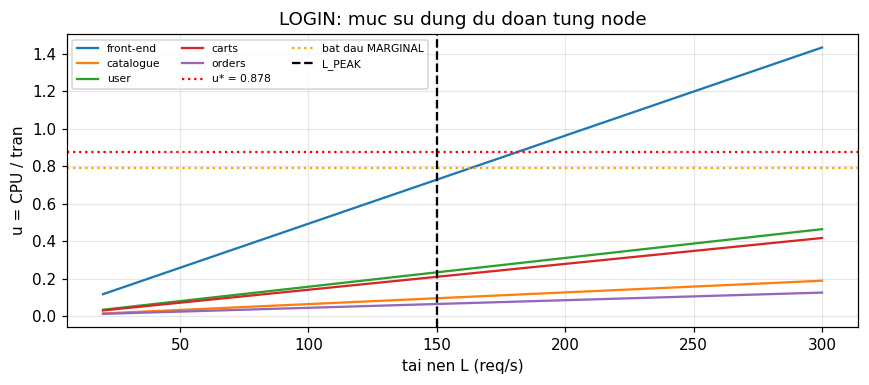

In [12]:
Ls = np.linspace(20, 300, 80)
fig, ax = plt.subplots(figsize=(8, 3.6))
for s in FP.SCORED:
    ax.plot(Ls, [PRED.utilization(L, **KW)[s] for L in Ls], label=s)
ax.axhline(PRED.u_star, color='red', ls=':', label=f'u* = {PRED.u_star:.3f}')
ax.axhline(PRED.u_star * (1 - PRED.margin), color='orange', ls=':', label='bat dau MARGINAL')
if CH['L_PEAK']: ax.axvline(CH['L_PEAK'], color='k', ls='--', label='L_PEAK')
ax.set_xlabel('tai nen L (req/s)'); ax.set_ylabel('u = CPU / tran'); ax.legend(fontsize=7, ncol=3)
ax.set_title(f'{ARCH}: muc su dung du doan tung node'); plt.tight_layout(); plt.show()

## 5. So với `assess()` chính thức

Đây là đúng hàm người dùng gọi (`src/agents/orchestrator.py`). Nó **luôn** dùng bản đóng băng và LLM của orchestrator
(offline nếu chưa có API key) — nên nếu bạn đã đổi cấu hình, hai kết quả sẽ khác nhau: đó chính là tác động của thay đổi.

In [13]:
# O nay goi AGENT THAT -> can LLM (dotenv + GOOGLE_API_KEY). Khong co thi BO QUA,
# khong de ca notebook vo: phan con lai khong phu thuoc LLM.
import importlib.util as _iu
_thieu = [m for m in ('dotenv',) if _iu.find_spec(m) is None]
if _thieu or not os.environ.get('GOOGLE_API_KEY'):
    print('BO QUA o nay:', 'thieu module ' + ', '.join(_thieu) if _thieu
          else 'khong co GOOGLE_API_KEY trong moi truong')
    print('Phan con lai cua notebook KHONG can LLM. De chay o nay: pip install python-dotenv'
          ' va dat GOOGLE_API_KEY (hoac ghi vao .env o goc repo).')
else:
    with quiet():
        from agents import orchestrator as ORCH
        chinh_thuc = ORCH.assess(CH['YEU_CAU'], L_peak=CH['L_PEAK'])
    sl = chinh_thuc['slo']
    f = sl['feasibility'] if sl else None
    so_sanh = pd.DataFrame({
        'assess() chinh thuc': {'archetype': (sl or chinh_thuc['forecast'])['parsed_requirement']['request_type'],
                                'Delta %': (sl or chinh_thuc['forecast'])['parsed_requirement']['injection_delta_pct'],
                                'Tang 1': chinh_thuc['forecast']['capacity_assessment']['status'],
                                'phan quyet': chinh_thuc['verdict'], 'R*': getattr(f, 'breakpoint_rps', None),
                                'mo hinh': getattr(f, 'model', None)},
        'notebook (cau hinh cua ban)': {'archetype': ARCH, 'Delta %': P['injection_delta_pct'], 'Tang 1': ca.status,
                                        'phan quyet': (ket_luan if CH['L_PEAK'] and not P['is_out_of_scope'] else None),
                                        'R*': round(R, 1) if CH['L_PEAK'] and not P['is_out_of_scope'] else None,
                                        'mo hinh': CH['CHE_DO'] + (' + k' if KK else '')}})
    display(so_sanh)

BO QUA o nay: thieu module dotenv
Phan con lai cua notebook KHONG can LLM. De chay o nay: pip install python-dotenv va dat GOOGLE_API_KEY (hoac ghi vao .env o goc repo).


Lưu ý: `assess()` chính thức **không truyền `k`** trừ khi bạn đưa vào, nên nó chạy P2 (k = 1). Notebook mặc định
`K='probe'` (P3) — đó là khác biệt duy nhất ở cấu hình mặc định.

---
## 6. 🧪 Bàn thực nghiệm — thử biến thể mô hình trên n = 10 tính năng tiến cứu

Cách dùng: viết một hàm `du_doan(tinh_nang) -> điểm gãy (req/s)`, rồi gọi `danh_gia(du_doan, 'tên')`. Hàm tự so với
đáp án đo được, với P3 đóng băng, với hai mốc nền, với sàn nhiễu — và ghi vào **bảng xếp hạng**.

Quy ước dấu: sai số **dương** = đoán điểm gãy **muộn** hơn thực tế = **khả thi giả** (nguy hiểm).

In [14]:
FEATS = ['login', 'register', 'wishlist', 'catsearch', 'account', 'preview', 'orderhist', 'related', 'reorder', 'orderfull']
LO, HI = {}, {}
for sp in sorted(bo('SS-PROSP2').glob('ramp_*/run*/steps.json')):
    j = json.load(open(sp, encoding='utf-8')); f = j.get('feature', 'base')
    if f != 'base' and (f not in FEATS or round(j['feature_pct'] / HARNESS.FEATURES[f]['anchor'], 3) != 1.0):
        continue
    LO.setdefault(f, []).append(j['breakpoint']['lo']); HI.setdefault(f, []).append(j['breakpoint']['hi'] or 1.25 * j['breakpoint']['lo'])
DAP_AN = {f: float(np.median(LO[f])) for f in FEATS}
P3_DB = {f: next(p['breakpoint_rps'] for p in json.load(open(FROZEN / f'predictions_frozen_RE2_P3_prosp_{f}.json', encoding='utf-8'))['predictions'] if p['scale'] == 1.0) for f in FEATS}
SAN_NHIEU = float(np.median([100 * (max(v) - min(v)) / np.median(v) for v in LO.values()]))

# SAN NHIEU THU HAI -- do tren MOI phien do, khong chi phien SS-PROSP2.
# Vi sao can: SS-PROSP2-R2/R3 va SS-PROSP4* la cac lan DO LAI cung tinh nang, cung he
# so, cung he thong. Chung phai cho cung dap an; thuc te thi khong.
LO_PHIEN, PHIEN = {}, {}
for sp in sorted((RAW / 'SS-PROSP2').glob('*/ramp_*/run*/steps.json')):
    j = json.load(open(sp, encoding='utf-8')); f = j.get('feature', 'base'); lo = j['breakpoint']['lo']
    if lo is None or (f != 'base' and (f not in FEATS or
                      round(j['feature_pct'] / HARNESS.FEATURES[f]['anchor'], 3) != 1.0)):
        continue
    LO_PHIEN.setdefault(f, []).append(lo)
    PHIEN.setdefault(f, set()).add(sp.parts[-4])
SAN_NHIEU_PHIEN = float(np.median([100 * (max(v) - min(v)) / np.median(v)
                                   for v in LO_PHIEN.values() if len(v) > 1]))
BANG_XEP_HANG = []

def danh_gia(du_doan, ten, in_chi_tiet=True):
    from scipy import stats
    pred = {f: float(du_doan(f)) for f in FEATS}
    e = pd.Series({f: 100 * (pred[f] - DAP_AN[f]) / DAP_AN[f] for f in FEATS})
    e3 = pd.Series({f: 100 * (P3_DB[f] - DAP_AN[f]) / DAP_AN[f] for f in FEATS})
    eo = pd.Series({f: 100 * (np.median(list(DAP_AN.values())) - DAP_AN[f]) / DAP_AN[f] for f in FEATS})
    nguy = [f for f in FEATS if pred[f] > np.median(HI[f])]
    giong_p3 = all(abs(pred[f] - P3_DB[f]) <= 0.05 for f in FEATS)        # P3 trong file lam tron 0,1 req/s
    p3 = 1.0 if giong_p3 else stats.wilcoxon(e.abs(), e3.abs()).pvalue
    po = stats.wilcoxon(e.abs(), eo.abs()).pvalue
    dong = {'bien the': ten, '|sai so| TB %': round(e.abs().mean(), 1), 'trung vi %': round(e.abs().median(), 1),
            'xau nhat %': round(e.abs().max(), 1), 'kha thi gia': len(nguy), 'p vs P3': round(p3, 3), 'p vs const_oracle': round(po, 3)}
    BANG_XEP_HANG[:] = [r for r in BANG_XEP_HANG if r['bien the'] != ten] + [dong]
    if in_chi_tiet:
        display(pd.DataFrame({'dap an': DAP_AN, 'du doan': pred, 'sai so %': e.round(1), 'P3 dong bang': P3_DB,
                              'sai so P3 %': e3.round(1)}).round(1))
        print(f"{ten}: |sai so| TB {dong['|sai so| TB %']}% (P3 {e3.abs().mean():.1f}%, san nhieu 1 phien {SAN_NHIEU:.1f}%, qua phien {SAN_NHIEU_PHIEN:.1f}%) | "
              f"kha thi gia {len(nguy)} {nguy} | Wilcoxon p vs P3 = {p3:.3f}")
    return dong

def xem_bang_xep_hang():
    d = pd.DataFrame(BANG_XEP_HANG).sort_values('|sai so| TB %').reset_index(drop=True)
    display(d); print(f'san nhieu phep do = {SAN_NHIEU:.1f}%  -- chenh lech nho hon muc nay giua hai bien the la CHUA phan biet duoc')

def diem_gay(f, **ghi_de):
    """diem gay cua tinh nang f (ten trong FEATS) theo bo du doan dung tu CAU_HINH, co the ghi de tung tham so.
    ghi_de: u_star, tran, p2, train_max, margin (bo du doan); mode, chain ('taxonomy'|'probe'|list), k ('probe'|None|dict), delta_nhan"""
    bd = dung_bo_du_doan(**{k: ghi_de[k] for k in ['u_star', 'tran', 'p2', 'train_max', 'margin'] if k in ghi_de})
    kcfg = ghi_de.get('k', 'probe')
    k = KDOC[f]['measured_per_use'] if kcfg == 'probe' else kcfg
    ch = ghi_de.get('chain', 'taxonomy')
    ch = None if ch == 'taxonomy' else (KDOC[f]['chain_measured'] if ch == 'probe' else ch)
    return bd.breakpoint(mode=ghi_de.get('mode', 'P2'), feature=f, scale=ghi_de.get('delta_nhan', 1.0), k=k, chain=ch)[0]

### E0 — kiểm chứng bàn: tái lập P3 đóng băng (phải cho **đúng** 9,5%)

In [15]:
danh_gia(lambda f: diem_gay(f, u_star='dong_bang', p2='dong_bang', train_max=150, tran='RE2'), 'E0 P3 dong bang (tai lap)');

,dap an,du doan,sai so %,P3 dong bang,sai so P3 %
login,155.0,181.8,17.3,181.8,17.3
register,155.0,181.8,17.3,181.8,17.3
wishlist,140.0,156.7,11.9,156.7,11.9
catsearch,195.0,181.8,-6.8,181.8,-6.8
account,125.0,118.6,-5.1,118.6,-5.1
preview,175.0,181.8,3.9,181.8,3.9
orderhist,155.0,171.4,10.6,171.4,10.6
related,175.0,176.0,0.6,176.0,0.6
reorder,100.0,81.4,-18.6,81.4,-18.6
orderfull,140.0,135.8,-3.0,135.8,-3.0


E0 P3 dong bang (tai lap): |sai so| TB 9.5% (P3 9.5%, san nhieu 1 phien 21.4%, qua phien 45.2%) | kha thi gia 0 [] | Wilcoxon p vs P3 = 1.000


### E1 — u* hiệu chỉnh theo phiên đo tiến cứu (nguồn sai số chính theo chẩn đoán)
⚠️ Dùng ramp `base` của chính phiên tiến cứu → đây là **hồi cứu**, chỉ để biết hướng cải tiến có đáng làm không.

In [16]:
danh_gia(lambda f: diem_gay(f, u_star='phien_tien_cuu'), 'E1 u* theo phien');

,dap an,du doan,sai so %,P3 dong bang,sai so P3 %
login,155.0,165.8,7.0,181.8,17.3
register,155.0,165.8,7.0,181.8,17.3
wishlist,140.0,142.9,2.1,156.7,11.9
catsearch,195.0,165.8,-15.0,181.8,-6.8
account,125.0,108.2,-13.5,118.6,-5.1
preview,175.0,165.8,-5.3,181.8,3.9
orderhist,155.0,156.4,0.9,171.4,10.6
related,175.0,160.6,-8.2,176.0,0.6
reorder,100.0,74.2,-25.8,81.4,-18.6
orderfull,140.0,123.9,-11.5,135.8,-3.0


E1 u* theo phien: |sai so| TB 9.6% (P3 9.5%, san nhieu 1 phien 21.4%, qua phien 45.2%) | kha thi gia 0 [] | Wilcoxon p vs P3 = 0.557


### E2 — P3 + chuỗi gọi đo được (thay chuỗi taxonomy)

In [17]:
danh_gia(lambda f: diem_gay(f, chain='probe'), 'E2 P3 + chain do duoc');

,dap an,du doan,sai so %,P3 dong bang,sai so P3 %
login,155.0,176.0,13.6,181.8,17.3
register,155.0,176.0,13.6,181.8,17.3
wishlist,140.0,156.7,11.9,156.7,11.9
catsearch,195.0,181.8,-6.8,181.8,-6.8
account,125.0,118.6,-5.1,118.6,-5.1
preview,175.0,170.7,-2.5,181.8,3.9
orderhist,155.0,171.4,10.6,171.4,10.6
related,175.0,176.0,0.6,176.0,0.6
reorder,100.0,81.4,-18.6,81.4,-18.6
orderfull,140.0,135.8,-3.0,135.8,-3.0


E2 P3 + chain do duoc: |sai so| TB 8.6% (P3 9.5%, san nhieu 1 phien 21.4%, qua phien 45.2%) | kha thi gia 0 [] | Wilcoxon p vs P3 = 0.557


### E3 — quét u*: sai số thay đổi thế nào theo ngưỡng?
Đường cong này cho thấy **độ nhạy** — và vì sao chọn u* bằng cách nhìn đường này là *gian lận* (fit trên đáp án).
Muốn chọn u* trung thực: dùng LOFO ở E5.

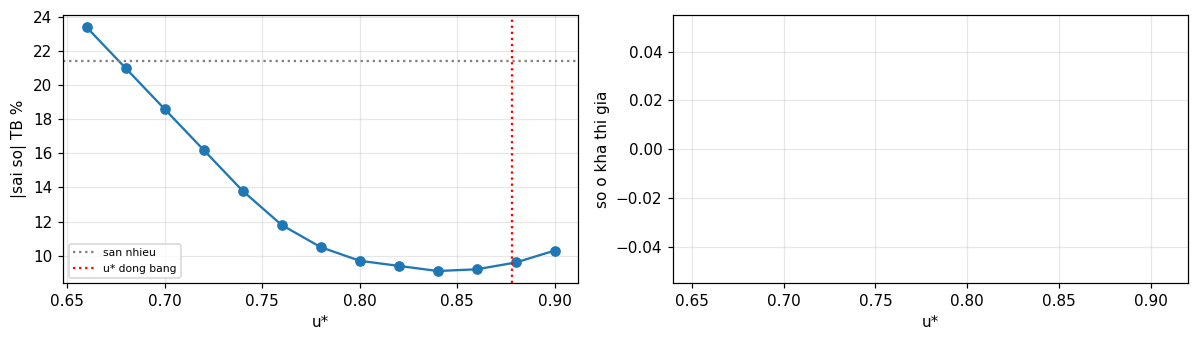

In [18]:
qu = np.round(np.arange(0.66, 0.92, 0.02), 2)
curve = [danh_gia(lambda f, u=u: diem_gay(f, u_star=u), f'quet u*={u}', in_chi_tiet=False) for u in qu]
BANG_XEP_HANG[:] = [r for r in BANG_XEP_HANG if not r['bien the'].startswith('quet u*')]    # khong dua vao bang xep hang
cv = pd.DataFrame(curve)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(qu, cv['|sai so| TB %'], 'o-'); ax[0].axhline(SAN_NHIEU, color='gray', ls=':', label='san nhieu')
ax[0].axvline(P2F['params']['u_star'], color='red', ls=':', label='u* dong bang'); ax[0].set_xlabel('u*'); ax[0].set_ylabel('|sai so| TB %'); ax[0].legend(fontsize=7)
ax[1].bar(qu, cv['kha thi gia'], width=.015); ax[1].set_xlabel('u*'); ax[1].set_ylabel('so o kha thi gia')
plt.tight_layout(); plt.show()

### E4 — độ nhạy theo Δ (hạn chế M5: Δ thật chưa bao giờ bị kiểm vì harness bơm đúng Δ)
Nếu ngoài đời Δ ước lượng sai ±50%, điểm gãy dự đoán lệch bao nhiêu?

In [19]:
nhan = [0.5, 0.75, 1.0, 1.25, 1.5]
dn = pd.DataFrame({f: [diem_gay(f, delta_nhan=m) for m in nhan] for f in FEATS}, index=[f'Delta x{m}' for m in nhan]).T
display((100 * (dn.div(dn['Delta x1.0'], axis=0) - 1)).round(1).rename(columns=lambda c: c + ' (% doi R*)'))

,Delta x0.5 (% doi R*),Delta x0.75 (% doi R*),Delta x1.0 (% doi R*),Delta x1.25 (% doi R*),Delta x1.5 (% doi R*)
login,6.4,3.1,0.0,-2.9,-5.7
register,6.4,3.1,0.0,-2.9,-5.7
wishlist,13.7,6.4,0.0,-5.7,-10.8
catsearch,6.4,3.1,0.0,-2.9,-5.7
account,27.1,11.9,0.0,-9.6,-17.6
preview,6.4,3.1,0.0,-2.9,-5.7
orderhist,9.3,4.4,0.0,-4.1,-7.8
related,8.0,3.8,0.0,-3.6,-6.9
reorder,43.5,17.9,0.0,-13.2,-23.3
orderfull,20.7,9.4,0.0,-7.9,-14.6


### E5 — mẫu LOFO: chọn tham số trung thực (bỏ một tính năng)
Với mỗi tính năng *f*: chọn u* tốt nhất trên **9 tính năng còn lại**, rồi dự đoán *f* bằng u* đó. Kết quả là ước lượng
trung thực của "u* hiệu chỉnh lại" — thay mẫu này bằng bất kỳ tham số nào bạn muốn fit.

In [20]:
LUOI_U = np.round(np.arange(0.60, 0.95, 0.01), 2)
bang_R = {u: {f: diem_gay(f, u_star=u) for f in FEATS} for u in LUOI_U}          # tinh truoc cho nhanh
def lofo_u(f_giu):
    con_lai = [g for g in FEATS if g != f_giu]
    loi = {u: np.mean([abs(bang_R[u][g] - DAP_AN[g]) / DAP_AN[g] for g in con_lai]) for u in LUOI_U}
    u_tot = min(loi, key=loi.get)
    return bang_R[u_tot][f_giu], u_tot
chon = {f: lofo_u(f)[1] for f in FEATS}
print('u* LOFO chon cho tung tinh nang bi giu lai:', chon)
danh_gia(lambda f: lofo_u(f)[0], 'E5 u* chon bang LOFO');

u* LOFO chon cho tung tinh nang bi giu lai: {'login': np.float64(0.87), 'register': np.float64(0.87), 'wishlist': np.float64(0.87), 'catsearch': np.float64(0.84), 'account': np.float64(0.84), 'preview': np.float64(0.87), 'orderhist': np.float64(0.87), 'related': np.float64(0.84), 'reorder': np.float64(0.84), 'orderfull': np.float64(0.84)}


,dap an,du doan,sai so %,P3 dong bang,sai so P3 %
login,155.0,180.0,16.1,181.8,17.3
register,155.0,180.0,16.1,181.8,17.3
wishlist,140.0,155.2,10.8,156.7,11.9
catsearch,195.0,173.6,-11.0,181.8,-6.8
account,125.0,113.3,-9.4,118.6,-5.1
preview,175.0,180.0,2.9,181.8,3.9
orderhist,155.0,169.8,9.5,171.4,10.6
related,175.0,168.2,-3.9,176.0,0.6
reorder,100.0,77.7,-22.3,81.4,-18.6
orderfull,140.0,129.8,-7.3,135.8,-3.0


E5 u* chon bang LOFO: |sai so| TB 10.9% (P3 9.5%, san nhieu 1 phien 21.4%, qua phien 45.2%) | kha thi gia 0 [] | Wilcoxon p vs P3 = 0.232


### Đọc E1–E5 (kết quả với cấu hình mặc định, chạy 28/09/2026)

| Biến thể | \|sai số\| TB | So với P3 (9,5%) |
|---|---|---|
| E1 u* theo phiên (0,803) | 9,6% | **không** tốt hơn: login/register/wishlist/orderhist bớt muộn, nhưng catsearch/account/related/reorder/orderfull thành quá sớm |
| E2 chain đo được | 8,6% | tốt hơn chút, p = 0,54 — chưa phân biệt được |
| E5 u* chọn bằng LOFO | 10,9% | **kém hơn** — chọn u* trung thực không cải thiện gì |

**Kết luận:** sai số **không phải một độ lệch chung** mà hạ một u* là sửa được. Các tính năng lệch theo **hai chiều ngược
nhau** — tuyến ghi phiên (login/register) vỡ sớm hơn dự đoán, còn đọc catalogue/đơn hàng vỡ muộn hơn. Muốn tiến bộ phải
có ngưỡng hoặc cơ chế **phụ thuộc loại tính năng** (vd. mô hình độ trễ/hàng đợi theo từng lớp request), không phải chỉnh
một hằng số. Mọi chênh lệch ở đây đều nhỏ hơn sàn nhiễu 21,4% → cần lưới đo mịn hơn trước khi xếp hạng chắc chắn.

*(Nếu bạn đổi cấu hình ở mục 0, các con số trên sẽ khác — bảng này ghi kết quả mặc định để đối chiếu.)*

### ✍️ Ô của bạn — viết biến thể mới ở đây

Ví dụ: đổi trần CPU front-end lên 0,6 core, hoặc tự viết một hàm dự đoán hoàn toàn mới (miễn trả về req/s):

In [21]:
# vi du 1: tran front-end 0.6 core (chi trong bo nho)
tran_moi = dict(limits['RE2']); tran_moi['front-end'] = 0.6
danh_gia(lambda f: diem_gay(f, tran=tran_moi), 'VD tran front-end 0.6', in_chi_tiet=False)

# vi du 2: ham tu viet -- P3 nhung u* giam 5% cho tinh nang quat-ra nhieu (Sum k >= 4)
def bien_the_cua_toi(f):
    sk = sum(v for s, v in KDOC[f]['measured_per_use'].items() if s != 'front-end')
    return diem_gay(f, u_star=P2F['params']['u_star'] * (0.95 if sk >= 4 else 1.0))
danh_gia(bien_the_cua_toi, 'VD u* giam cho quat-ra', in_chi_tiet=False)

xem_bang_xep_hang()

,bien the,|sai so| TB %,trung vi %,xau nhat %,kha thi gia,p vs P3,p vs const_oracle
0,E2 P3 + chain do duoc,8.6,8.7,18.6,0,0.557,0.375
1,E0 P3 dong bang (tai lap),9.5,8.7,18.6,0,1.000,0.492
2,E1 u* theo phien,9.6,7.6,25.8,0,0.557,0.275
3,VD u* giam cho quat-ra,10.4,10.3,22.8,0,0.922,0.625
4,E5 u* chon bang LOFO,10.9,10.2,22.3,0,0.232,0.695
5,VD tran front-end 0.6,24.3,23.2,41.3,5,0.014,0.232


san nhieu phep do = 21.4%  -- chenh lech nho hon muc nay giua hai bien the la CHUA phan biet duoc


## 6b. ⚠️ Đại lượng đang dự đoán có ổn định không? — **sàn nhiễu thật**

Mọi con số ở E0–E5 được so với `san nhieu` = độ trải của `lo` giữa các lần lặp **trong một
phiên đo**. Nhưng `SS-PROSP2-R2`, `SS-PROSP2-R3`, `SS-PROSP4*` là các lần **đo lại** đúng
những tính năng đó, đúng hệ số, trên đúng hệ thống — chúng phải cho cùng đáp án.

Ô dưới đo cả hai sàn, và đo cả năng lực **cơ sở** (`ramp_base`, *không có tính năng nào*)
theo từng phiên. Đây là phép kiểm quan trọng nhất của notebook: nó chặn trên mọi điều mà
bất kỳ mô hình nào trong đây có thể tuyên bố. Nếu chính đại lượng cần dự đoán không tái
lập được giữa các phiên, thì sai số mô hình nhỏ hơn độ trôi đó **không chứng minh được gì**.

In [22]:
# ---- hai san nhieu, va do troi cua nang luc CO SO ----
bang = pd.DataFrame({
    'n (1 phien)': {f: len(LO[f]) for f in FEATS},
    'dap an (1 phien)': {f: float(np.median(LO[f])) for f in FEATS},
    'trai 1 phien %': {f: round(100 * (max(LO[f]) - min(LO[f])) / np.median(LO[f]), 1) for f in FEATS},
    'n (moi phien)': {f: len(LO_PHIEN[f]) for f in FEATS},
    'dap an (moi phien)': {f: float(np.median(LO_PHIEN[f])) for f in FEATS},
    'trai moi phien %': {f: round(100 * (max(LO_PHIEN[f]) - min(LO_PHIEN[f])) / np.median(LO_PHIEN[f]), 1) for f in FEATS},
    'so phien': {f: len(PHIEN[f]) for f in FEATS}})
bang['dap an doi'] = np.where(bang['dap an (1 phien)'] != bang['dap an (moi phien)'], 'CO', '')
display(bang)
print(f"san nhieu trung vi:  trong 1 phien = {SAN_NHIEU:.1f}%   qua moi phien = {SAN_NHIEU_PHIEN:.1f}%"
      f"   (rong gap {SAN_NHIEU_PHIEN / SAN_NHIEU:.1f} lan)")
print(f"so tinh nang doi dap an khi tinh them cac phien: {(bang['dap an doi'] == 'CO').sum()}/{len(FEATS)}")

# Nang luc CO SO: khong co tinh nang nao, nen moi phien PHAI cho cung so.
co_so = {}
for sp in sorted(RAW.glob('SS-*/ramp_base/run*/steps.json')) + sorted(RAW.glob('SS-*/*/ramp_base/run*/steps.json')):
    lo = json.load(open(sp, encoding='utf-8'))['breakpoint']['lo']
    if lo is not None:
        co_so.setdefault(sp.parts[-4], []).append(lo)
cs = pd.Series({k: f"{sorted(v)}" for k, v in sorted(co_so.items())}, name='lo cua ramp_base')
display(cs.to_frame())
tat = [x for v in co_so.values() for x in v]
print(f"nang luc CO SO qua {len(co_so)} phien do: {min(tat)} - {max(tat)} req/s "
      f"(gap {max(tat) / min(tat):.2f} lan), trung vi {np.median(tat):.0f}")

,n (1 phien),dap an (1 phien),trai 1 phien %,n (moi phien),dap an (moi phien),trai moi phien %,so phien,dap an doi
login,4,155.0,19.4,8,155.0,35.5,3,
register,4,155.0,45.2,8,155.0,61.3,3,
wishlist,4,140.0,21.4,8,125.0,60.0,3,CO
catsearch,4,195.0,0.0,8,195.0,48.7,3,
account,4,125.0,44.0,8,125.0,44.0,3,
preview,4,175.0,22.9,8,155.0,45.2,3,CO
orderhist,4,155.0,25.8,8,155.0,45.2,3,
related,4,175.0,22.9,8,155.0,45.2,3,CO
reorder,3,100.0,0.0,10,100.0,20.0,4,
orderfull,4,140.0,21.4,15,125.0,60.0,4,CO


san nhieu trung vi:  trong 1 phien = 21.4%   qua moi phien = 45.2%   (rong gap 2.1 lan)
so tinh nang doi dap an khi tinh them cac phien: 4/10


,lo cua ramp_base
SS-LIMITS,"[160, 160, 220, 220, 220]"
SS-LIMITS-C2,[120]
SS-LIMITS-CLEAN,[220]
SS-LIMITS-INDEP,"[180, 200]"
SS-LIMITS-PROSP,[140]
SS-PROSP2,"[155, 155, 195, 195, 195, 195, 195, 195]"
SS-PROSP2-R2,"[125, 155]"
SS-PROSP2-R3,"[195, 195]"
SS-PROSP4,"[155, 155]"
SS-PROSP4-CLEAN,"[155, 155, 155, 155, 155, 155]"


nang luc CO SO qua 16 phien do: 120 - 240 req/s (gap 2.00 lan), trung vi 155


### Đọc kết quả 6b

Hai điều đọc được, và cả hai đều giới hạn những gì bài báo được phép nói:

1. **Sàn nhiễu gấp đôi** khi tính các phiên đo lại. `catsearch` trông ổn định tuyệt đối
   (0% trải trong một phiên) nhưng trải gần 50% khi tính cả ba phiên. Sàn trong-một-phiên
   **đánh giá thấp** độ bất định thật.
2. **Năng lực cơ sở không tái lập được.** `ramp_base` không có tính năng nào, nên mọi phiên
   phải cho cùng một số. Thực tế trải từ 125 đến 240 req/s. `SS-LIMITS` cho 220 ở ba run
   nhưng 160 khi đo lại cùng ngày hôm đó.

Hệ quả cho cách viết bài: **không** tuyên bố "mô hình đạt sai số 9,5%" như một thuộc tính
của mô hình. Con số đó đúng cho *một phiên đo*, và độ trôi của chính đại lượng cần dự đoán
giữa các phiên còn lớn hơn nó. Đây chính là lý do bài báo chuyển từ *dự phóng chính xác
metric* sang *phán quyết khả thi an toàn*: phán quyết chịu được độ trôi này, còn một con
số req/s thì không. Khi so hai mô hình, phải dùng phép ghép cặp trên cùng phiên
(E0–E5 làm đúng vậy — Wilcoxon ghép cặp), **không** so hai số trung bình rời nhau.

## 6c. Δ do **Parser** dự đoán — sai bao nhiêu, và sai đó có đổi phán quyết không?

Toàn bộ E0–E5 giả định Δ **đúng bằng anchor**, vì harness bơm đúng anchor. Nhưng trong hệ thật
Δ do ParserAgent sinh ra từ một câu yêu cầu bằng ngôn ngữ tự nhiên. Đây là **hạn chế M5** — mắt
xích duy nhất của đường ống chưa bao giờ bị kiểm **đến tận phán quyết**.

Mục này nối hai đầu: lấy **phân bố sai số thật** của Parser (600 lượt đo, 4 cấu hình × 50 prompt
× 3 lần lặp, `parser_ablation_benchmark.csv`) rồi truyền qua bộ dự đoán khả thi, đếm xem bao
nhiêu **quyết định bị lật** so với khi Δ đúng anchor. Khác §E4: E4 quét Δ ×{0,5…1,5} *giả định*;
ở đây dùng sai số **đã đo được**.

> **Phải nói rõ phép này đo gì.** `expected_anchor` là **bảng taxonomy của chính chúng tôi**, nên
> "sai số" ở đây là *độ lệch khỏi bảng anchor*, **không phải** độ đúng so với thực tế — và
> [nb01 §B1.5](01_du_lieu_do_thi_nhan_qua_va_du_doan.ipynb) đã cho thấy taxonomy sai chuỗi gọi ở
> 11/18 tính năng. Vậy đây là **phân tích độ nhạy** (lệch Δ tốn bao nhiêu), không phải phép
> *thẩm định* Δ. Muốn thẩm định thì phải đo Δ thật của một tính năng mới trên hệ thật — chưa làm.

In [23]:
AB = pd.read_csv(ROOT / 'data/processed/scm_results/parser_ablation_benchmark.csv')
AB['sai_diem'] = AB.pred_delta - AB.expected_anchor          # diem phan tram cua Delta
print(f"{len(AB)} luot | {AB.prompt_id.nunique()} prompt x {AB.repeat_id.nunique()} lan lap "
      f"x {AB.model.nunique()} cau hinh | backend: {AB.llm_backend.unique()[0]}")
display(AB.groupby('model').agg(n=('sai_diem', 'size'), MAE_diem=('abs_error', 'mean'),
                                trung_vi=('abs_error', 'median'), xau_nhat=('abs_error', 'max'),
                                lech_TB=('sai_diem', 'mean'), do_lech=('sai_diem', 'std'),
                                vi_pham_bien=('physical_boundary_violation', 'mean'),
                                ao_dich_vu=('service_hallucination', 'mean')).round(2))
print('MAE (diem %) theo nhom cau hoi:')
display(AB.pivot_table(index='category', columns='model', values='abs_error', aggfunc='mean').round(2))

600 luot | 50 prompt x 3 lan lap x 4 cau hinh | backend: LIVE_gemini-flash-lite-latest


,n,MAE_diem,trung_vi,xau_nhat,lech_TB,do_lech,vi_pham_bien,ao_dich_vu
model,,,,,,,,
Guarded_Hybrid_Parser,150,1.57,0.0,15.0,0.37,3.98,0.00,0.00
Rule_Only,150,2.80,0.0,20.0,-1.20,5.73,0.00,0.00
Unguarded_FewShot_LLM,150,38.60,0.0,975.0,31.80,154.62,0.15,0.02
Unguarded_ZeroShot_LLM,150,844.61,25.0,49980.0,838.21,5775.33,0.38,0.91


MAE (diem %) theo nhom cau hoi:


model,Guarded_Hybrid_Parser,Rule_Only,Unguarded_FewShot_LLM,Unguarded_ZeroShot_LLM
category,,,,
Adversarial_Stress,2.00,2.5,180.50,3683.37
Complex_MultiHop,2.50,4.5,3.50,415.17
In_Distribution,0.67,2.5,3.33,57.50
Subtle_ReadOnly,2.00,2.0,2.33,9.50


In [24]:
# ---- truyen sai so Delta cua Parser vao PHAN QUYET ----
# `scale` trong FeasibilityPredictor la boi so tren Delta (xem FP.spec), nen sai so e diem
# tren anchor A tuong duong scale = (A + e) / A.
HI_TV = {f: float(np.median(HI[f])) for f in FEATS}

def dem(sc_theo_tinh_nang):
    """Dem quyet dinh dung / NGUY HIEM (bao kha thi nhung that ra khong) / bao thu.
    Chi tinh cac muc tai NGOAI dai nhap nhang [lo, hi) -- trong dai do dap an that khong xac dinh."""
    dung = nguy = thu = tong = 0
    for f in FEATS:
        for sc in sc_theo_tinh_nang(f):
            for L in P2F['params']['grid_rps']:
                if L < DAP_AN[f]:
                    that = True
                elif L >= HI_TV[f]:
                    that = False
                else:
                    continue
                kt = str(BO_DU_DOAN.verdict(L, feature=f, scale=sc, mode='P2')
                         .get('verdict', '')).upper() != 'INFEASIBLE'
                tong += 1
                dung += (kt == that)
                nguy += (kt and not that)
                thu += (not kt and that)
    return dict(n=tong, dung_pct=round(100 * dung / tong, 2),
                NGUY_HIEM=nguy, nguy_pct=round(100 * nguy / tong, 2), bao_thu=thu)

BO_DU_DOAN = dung_bo_du_doan(u_star='dong_bang', p2='dong_bang', train_max=150, tran='RE2')
hang = {'Δ ĐÚNG anchor (mốc)': dem(lambda f: [1.0])}
for m, g in AB.groupby('model'):
    hang[m] = dem(lambda f, g=g: [max((HARNESS.FEATURES[f]['anchor'] + e)
                                      / HARNESS.FEATURES[f]['anchor'], 1e-6) for e in g.sai_diem.values])
KQ = pd.DataFrame(hang).T
display(KQ)
m0 = KQ.loc['Δ ĐÚNG anchor (mốc)']
print(f"Parser co guard lam mat {m0.dung_pct - KQ.loc['Guarded_Hybrid_Parser'].dung_pct:.2f} diem "
      f"do dung so voi Delta hoan hao; ti le NGUY HIEM {m0.nguy_pct}% -> "
      f"{KQ.loc['Guarded_Hybrid_Parser'].nguy_pct}%")
print(f"Chi dung luat (khong LLM) mat {m0.dung_pct - KQ.loc['Rule_Only'].dung_pct:.2f} diem, "
      f"ti le NGUY HIEM len {KQ.loc['Rule_Only'].nguy_pct}%")

,n,dung_pct,NGUY_HIEM,nguy_pct,bao_thu
Δ ĐÚNG anchor (mốc),101.0,100.00,0.0,0.00,0.0
Guarded_Hybrid_Parser,15150.0,99.37,24.0,0.16,72.0
Rule_Only,15150.0,98.85,102.0,0.67,72.0
Unguarded_FewShot_LLM,15150.0,95.11,84.0,0.55,657.0
Unguarded_ZeroShot_LLM,15150.0,81.29,78.0,0.51,2756.0


Parser co guard lam mat 0.63 diem do dung so voi Delta hoan hao; ti le NGUY HIEM 0.0% -> 0.16%
Chi dung luat (khong LLM) mat 1.15 diem, ti le NGUY HIEM len 0.67%


### Đọc kết quả 6c

| cấu hình Δ | n quyết định | đúng | NGUY HIỂM | bảo thủ |
|---|---|---|---|---|
| **Δ đúng anchor** (mốc) | 101 | 100,00% | 0 (0,00%) | 0 |
| **Guarded_Hybrid_Parser** | 15 150 | 99,37% | 24 (**0,16%**) | 72 |
| Rule_Only (không LLM) | 15 150 | 98,85% | 102 (**0,67%**) | 72 |
| Unguarded_FewShot_LLM | 15 150 | 95,11% | 84 (0,55%) | 657 |
| Unguarded_ZeroShot_LLM | 15 150 | 81,29% | 78 (0,51%) | **2 756** |

Bốn điều đọc được:

1. **Parser có guard gần như không tốn gì.** Mất **0,63 điểm** độ đúng so với Δ hoàn hảo, và tỉ lệ
   **nguy hiểm** chỉ từ 0,00% lên **0,16%** (24/15 150). Nói cách khác, mắt xích chưa được kiểm
   (M5) **không phải** nguồn rủi ro chính của đường ống — độ trôi của hệ ở §6b lớn hơn nhiều.
2. **Guard là phần đóng góp, không phải LLM.** `Unguarded_ZeroShot` có MAE **844,61 điểm %**,
   **91%** ảo tên dịch vụ, **38%** vi phạm biên vật lý, `pred_delta` lên tới **49 980**. Cùng LLM,
   cùng backend, chỉ thêm sáu guard → MAE **1,57 điểm**, 0% ảo, 0% vi phạm biên. Đây là con số nên
   đưa vào bài báo cho RQ về parser.
3. **LLM chỉ hơn luật thuần 0,52 điểm** độ đúng (99,37% vs 98,85%). Phần hơn thật nằm ở *an toàn*:
   luật thuần đẩy số ca nguy hiểm từ 24 lên **102** — gấp hơn **4 lần** (0,16% → 0,67%). Đó là lý
   do giữ LLM, **không** phải vì nó chính xác hơn.
4. **Cẩn thận với `Unguarded_ZeroShot` trông "an toàn"** (0,51% nguy hiểm, thấp hơn cả Rule_Only).
   Đó là giả: nó phóng Δ lên hàng nghìn phần trăm nên tuyên bố **mọi thứ** không khả thi — **2 756**
   quyết định bảo thủ sai, gấp 38 lần bản có guard. Một bộ dự đoán luôn nói "không" có 0% nguy hiểm
   và 0% hữu dụng. Đây đúng là lý do phải báo cáo **cả hai** trục (phủ × độ chặt), không bao giờ một.

**Hai giới hạn phải ghi trong bài:**

- Phép này đo *độ lệch khỏi bảng anchor của chúng tôi*, **không** đo độ đúng của Δ so với thực tế.
  Bảng anchor chưa được thẩm định độc lập, và [B1.5](01_du_lieu_do_thi_nhan_qua_va_du_doan.ipynb)
  cho thấy phần taxonomy đi kèm nó sai chuỗi gọi ở 11/18 tính năng. Muốn thẩm định Δ thật phải đo
  một tính năng mới trên hệ thật rồi so Δ quan sát với Δ Parser dự đoán — **chưa làm**, vẫn là M5.
- Mốc "Δ đúng anchor" ở đây đạt 100,00% trên 101 quyết định vì nó dùng đáp án của **một phiên**
  (`SS-PROSP2`), đúng như toàn bộ E0–E5. Gộp cả các phiên đo lại (§6b) thì mốc này còn 99,0% và
  xuất hiện 1 ca nguy hiểm — tức con số 100% là *thuộc tính của phiên đo*, không phải của mô hình.


## 7. Khi một biến thể đáng giữ — đưa vào hệ thống thật

| Bước | Việc | Vì sao |
|---|---|---|
| 1 | Kiểm lại bằng **LOFO** (mẫu E5) nếu biến thể có tham số fit | n = 10: fit thẳng trên đáp án luôn "thắng" |
| 2 | Thêm thành **chế độ mới** (vd `mode='P4'`) trong `src/scm/feasibility_predictor.py`; **không sửa** P0–P3 | bản đóng băng phải tái lập đúng từng bit |
| 3 | Viết test trong `tests/`, chạy `pytest tests -q` | bắt lỗi hồi quy |
| 4 | Đóng băng bằng `freeze_predictions.py` / `freeze_p3_prospective.py`, rồi **commit và push ngay** | hash chứng minh nội dung, **git trên remote** chứng minh thời điểm |
| 5 | Agent mù cài **tính năng mới** → probe → ramp → chấm | chỉ bước này mới là **tiến cứu** |

Chỗ cắm trong hệ thống: `NewFeatureFeasibilityAgent.assess(..., model='P4')` → `orchestrator.assess()`.